In [ ]:
#Final Project: Destiny Meredith 
#Research Question: 
#Do bar exam passage rates differ across racial groups, and to what extent 
#are those difference explained by LSAT scores and undergraduate GPA? 

#This project will exlore whether observed racial disparities in bar passage rates persist after accounting for differences in academic preparation
#, measured by LSAT scores and undergraduate GPA. 

In [ ]:
#Step 1: Load the Dataset 
import pandas as pd  

df = pd.read_csv("bar_pass_prediction.csv")

print(df.shape)
df.head()

(22407, 39)


,decile1b,decile3,ID,decile1,sex,race,cluster,lsat,ugpa,zfygpa,...,hisp,pass_bar,bar,bar_passed,tier,index6040,indxgrp,indxgrp2,dnn_bar_pass_prediction,gpa
0,10.0,10.0,2,10.0,1.0,7.0,1.0,44.0,3.5,1.33,...,0,1,a Passed 1st time,True,4.0,886.842082,g 700+,i 820+,0.979804,3.5
1,5.0,4.0,3,5.0,1.0,7.0,2.0,29.0,3.5,-0.11,...,0,1,a Passed 1st time,True,2.0,649.999987,f 640-700,f 640-700,0.979804,3.5
2,3.0,2.0,36,3.0,2.0,7.0,3.0,36.0,3.5,-0.64,...,0,1,a Passed 1st time,True,3.0,760.526298,g 700+,h 760-820,0.979804,3.5
3,7.0,4.0,52,7.0,2.0,7.0,3.0,39.0,3.5,0.34,...,0,1,a Passed 1st time,True,3.0,807.894717,g 700+,h 760-820,0.979804,3.5
4,9.0,8.0,55,9.0,2.0,7.0,4.0,48.0,3.5,1.02,...,0,1,a Passed 1st time,True,5.0,949.999974,g 700+,i 820+,0.979804,3.5


In [17]:
#Step 2: For Loop With Running Counter 
#This counts how many students passed the bar exam in the first 100 rows.  
#The counter tracks total number of passes. 

count = 0 

for i in range(100): 
    if df.loc[i, "bar_passed"] == True: 
        count = count + 1 

print("Number of students who passed (first 100 rows):", count)

Number of students who passed (first 100 rows): 95


In [ ]:
#Step 3: Conditional Logic (if / elif / else) 
#I apply different logic depending on the LSAT score (real dataset value). 

lsat_score = df.loc[0, "lsat"]

#Branch 1: Low LSAT Scores 
if lsat_score < 30: 
    print("Preprocessing: This student has a low LSAT score") 

#Branch 2: Medium LSAT Scores
elif lsat_score < 40: 
    print("Preprocessing: This student has a medium LSAT score")

#Branch 3: Highest LSAT Scores 
else: 
    print("Preprocessing: This student has a high LSAT score")

Preprocessing: This student has a high LSAT score


In [14]:
#Step 4: Define and Use A Function 
#This function will calculate bar passage rates for students above a given LSAT threshold 

def bar_pass_rate_by_lsat(threshold): 
    """
    Returns the bar passage rate for students with LSAT scores above a given threshold. 

    Parameters: 
    float: LSAT cutoff value

    Returns: 
    float: proporation of students who passed the bar exam 
    """

    filtered = df[df["lsat"] > threshold] 
    return filtered["bar_passed"].mean() 

#Call 1 
result1 = bar_pass_rate_by_lsat(30)
print("Bar passage rate (LSAT > 30):", result1) 

#Call 2 
result2 = bar_pass_rate_by_lsat(40)
print("Bar passage rate (LSAt > 40):", result2)

Bar passage rate (LSAT > 30): 0.9669794572660411
Bar passage rate (LSAt > 40): 0.9860796937532625


In [15]:
import numpy as np 

#Step 5: Numpy Array Indexing 
#This code will extract dataset columns into NumpPy arrays and perform basic operations. 

#Convert columns to Numpy arrays 
lsat_array = df["lsat"].to_numpy()
gpa_array = df["gpa"].to_numpy()
pass_array = df["bar_passed"].to_numpy()

#1. Vectorized operation: mean LSAT and GPA 
print("Mean LSAT score:", np.mean(lsat_array)) 
print("Mean GPA:", np.mean(gpa_array))

#2. Boolean masking: students who passed the bar exam 
passed_students = pass_array[pass_array == True]
print("Number of students who passed (NumpPy mas):", len(passed_students))

#3. Index access: retrieve specific element 
print("first LSAT score:", lsat_array[0])
print("First GPA:", gpa_array[0])


Mean LSAT score: 36.76790735038158
Mean GPA: 3.2154505288525908
Number of students who passed (NumpPy mas): 21237
first LSAT score: 44.0
First GPA: 3.5


In [34]:
#Step 6: Dictionary Manipulation 
#Store bar passage rates for each racial group in a dictionary 

results = {} 

for i in range(len(df)): 
    race = df.loc[i, "race1"] 
    passed = df.loc[i, "bar_passed"]

    if race not in results: 
        results[race] = [0, 0]

    results[race][1] += 1

    if passed == True: 
        results[race][0] += 1 

for race in results: 
    results[race] = results[race][0] / results[race][1] 

print("Bar passage rates by race (race1):")
print(results)

Bar passage rates by race (race1):
{'white': 0.9663389613165206, 'hisp': 0.875365141187926, 'asian': 0.9219620958751393, 'black': 0.7781087118391661, nan: 0.875, 'other': 0.8970588235294118}


<function matplotlib.pyplot.show(close=None, block=None)>

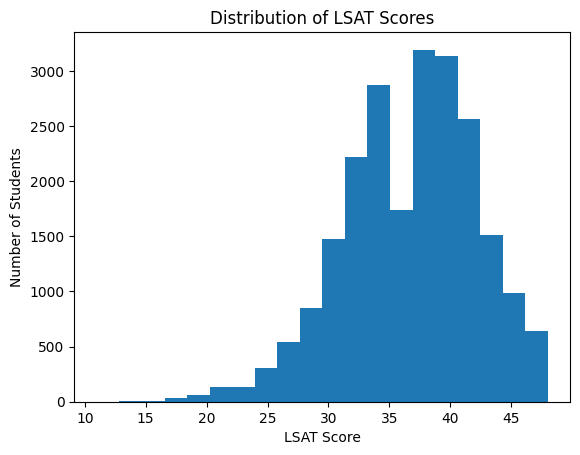

In [35]:
import matplotlib.pyplot as plt 

#Step 7: Two Plots With Matplotlib - Part A
#The first plot depicts a histogram of the distribution of LSAT Scores & the second plot depicts a bar chart that shows how bar passage rates differ across racial group. 

#Histogram of LSAT Scores 
plt.hist(df["lsat"], bins=20)
plt.title("Distribution of LSAT Scores") 
plt.xlabel("LSAT Score") 
plt.ylabel("Number of Students")
plt.show

The histogram shows that most LSAT scores are concentrated in the middle range, with fewer students having very low or very high scores. The highest number of scores appears to be between 33 and 43, and the median also seems to fall near the center of the graph. This shape is roughly bell-shaped with a Gaussian distribution.  

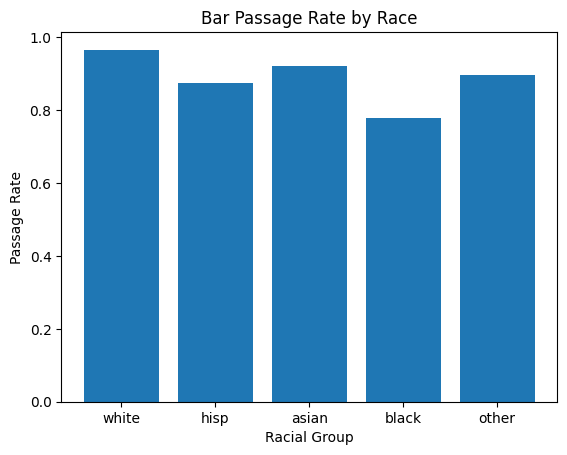

In [39]:
#Step 7: Two Plots With Matplotlib - Part B
#Bar chart - bar passage rates differ across racial group. 

results = {} 

for i in range(len(df)): 
    race = df.loc[i, "race1"]
    passed = df.loc[i, "bar_passed"]

    #Skip missing values 
    if race != race: 
        continue 

    if race not in results: 
        results[race] = [0, 0]

    results[race][1] += 1 

    if passed == True: 
        results[race][0] += 1

for race in results: 
    results[race] = results[race][0] / results[race][1]


plt.bar(results.keys(), results.values())

plt.title("Bar Passage Rate by Race")
plt.xlabel("Racial Group") 
plt.ylabel("Passage Rate") 
plt.show()


I chose a bar chart because it is good for comparing values across different racial groups. The chart shows the difference in bar passage rates across racial groups. White students have the highest passage rate, while Black students have the lowest. Asian, Hispanic, and other groups fall in between these values. This shows that bar passage outcomes are not equal across different racial groups. 

In [ ]:
#Step 8: Linear Regression 
#Tests whether LSAT scores can predict bar passage outcomes.  

from sklearn.linear_model import LinearRegression

#features (inputs) 
X = df[["lsat"]]
y = df["bar_passed"].astype(int)

model = LinearRegression()
model.fit(X, y)

print(model.score(X,y))

0.056763241335125225
